In [70]:
import xarray as xr
import seaborn as sns
import warnings
import numpy as np
import scipy.stats as stats
from scipy.stats import pearsonr
from scipy.stats import gamma, norm
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import glob
import datetime
import matplotlib.pyplot as plt
import pickle
import cartopy.crs as ccrs
from sklearn.preprocessing import QuantileTransformer
import cartopy.feature as cfeature
from scipy.stats import spearmanr
from matplotlib.colors import Normalize
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.interpolate import griddata
import seaborn as sns
import os
import matplotlib.colors as mcolors
from matplotlib.colors import TwoSlopeNorm
from sklearn.metrics import silhouette_score
from scipy.stats import pearsonr
from pathlib import Path
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
pd.options.mode.chained_assignment = None
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [71]:
base_path = os.path.expanduser("~/data/era5sgp/era5_sl_daily_total_precip_full_sgp")

# Collect all .nc files from 2001 to 2018

all_files = []

for year in range(1988, 2025):
    
    year_path = os.path.join(base_path, str(year))
    
    files = glob.glob(os.path.join(year_path, "*.nc"))
    
    all_files.extend(files)

In [72]:
# daily total precipitation for all grid points 

daily_p = xr.open_mfdataset(all_files, combine="by_coords")

daily_p['tp'] = daily_p['tp'] * 1000 # converting total precipitation from m to mm

In [73]:
# calculate sum of precipitation for every month and gridpoint in warm-season 

monthly_tp = daily_p['tp'].resample(valid_time='1MS').sum()

monthly_precip_df = monthly_tp.to_dataframe(name="monthly_tp").reset_index()

monthly_precip_df["year"] = monthly_precip_df["valid_time"].dt.year

monthly_precip_df["month"] = monthly_precip_df["valid_time"].dt.month

# filter for only warm-season

monthly_precip_df = monthly_precip_df[monthly_precip_df['month'].isin([5, 6, 7, 8, 9])]

for SPI calculation: 

we have data for days in: may, june, july, august, september for over 30 years 

for every gridpoint, calculate SPI for: may-june-july, june-july-august, july-august-september

take average of all three SPI's for every gridpoint

In [79]:
def compute_spi_series(precip_series):
    
    precip = precip_series.values
        
    try:
        
        fit_alpha, fit_loc, fit_beta = gamma.fit(precip, floc=0)
        
        cdf = gamma.cdf(precip, a=fit_alpha, loc=fit_loc, scale=fit_beta)
        
        spi = norm.ppf(cdf)
    
    except Exception as e:
        
        print("SPI fit failed:", e)
        
        spi = np.full_like(precip, np.nan, dtype=np.float64)
    
    return pd.Series(spi, index=precip_series.index)

In [80]:
spi_results = []

windows = [
    
    (5, 6, 7),  # May-Jun-Jul
    
    (6, 7, 8),  # Jun-Jul-Aug
    
    (7, 8, 9)   # Jul-Aug-Sep

]

for months in windows:
    
    sub = monthly_precip_df[monthly_precip_df["month"].isin(months)].copy()
    
    # Step 2: sum precip across those months for each year/gridpoint
    
    summed = sub.groupby(["latitude", "longitude", "year"], as_index=False)["monthly_tp"].sum()
    
    # Step 3: compute SPI across years for each gridpoint
    
    summed["spi"] = (
        
        summed.groupby(["latitude", "longitude"], group_keys=False)
              
        .apply(lambda g: compute_spi_series(g["monthly_tp"]))
    )
    
    summed["window"] = f"{months[0]}-{months[-1]}"
    
    spi_results.append(summed)

# Combine all windows

all_spi = pd.concat(spi_results, ignore_index=True)

# Step 4: Average the three SPI values for each year/gridpoint

spi_df = (all_spi.groupby(["latitude", "longitude", "year"], as_index=False)["spi"].mean()
           
           .rename(columns={"spi": "spi_3mo_avg"}))

/tmp/ipykernel_33069/1686639530.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summed.groupby(["latitude", "longitude"], group_keys=False)
/tmp/ipykernel_33069/1686639530.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summed.groupby(["latitude", "longitude"], group_keys=False)
/tmp/ipykernel_33069/1686639530.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This

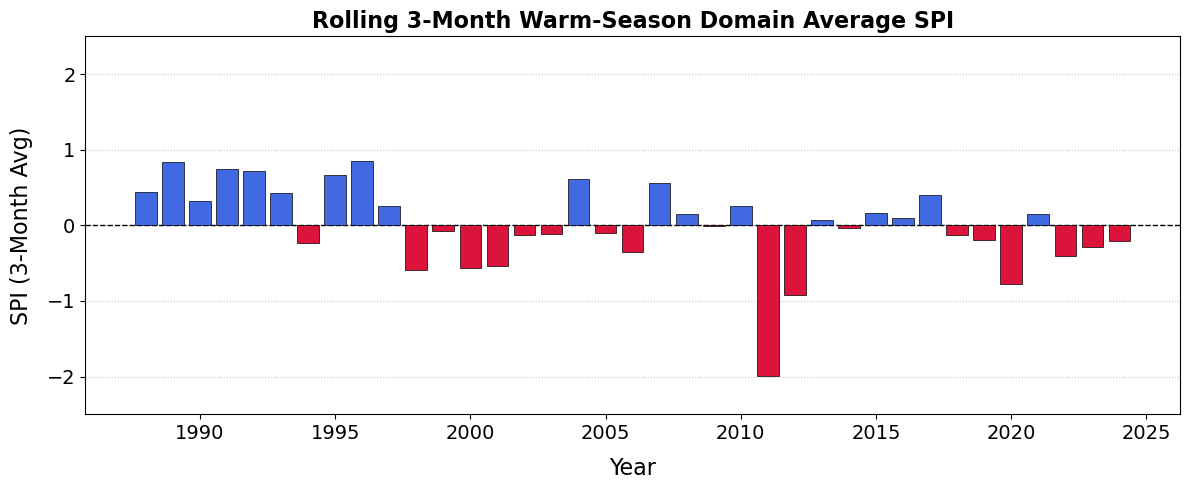

In [81]:
domain_average_spi = (
    
    spi_df.groupby("year")["spi_3mo_avg"].mean().reset_index(name="spi_avg"))

# 2. Function to color bars based on sign

def spi_color(spi):
    
    return "crimson" if spi < 0 else "royalblue"

colors = domain_average_spi["spi_avg"].apply(spi_color)

# 3. Plot
plt.figure(figsize=(12, 5))

# Bar plot
plt.bar(domain_average_spi["year"], domain_average_spi["spi_avg"], color=colors, zorder=3, edgecolor='black', linewidth=0.5)

# Zero line
plt.axhline(0, color="black", linestyle="--", linewidth=1)

# Axis labels and title
plt.ylabel("SPI (3-Month Avg)", fontsize=16, labelpad=10)

plt.xlabel("Year", fontsize=16, labelpad=10)

plt.title("Rolling 3-Month Warm-Season Domain Average SPI", fontsize=16, weight='bold')

# Ticks
plt.xticks(fontsize=14)

plt.yticks(fontsize=14)

# Y-axis range (optional — adjust if needed)
plt.ylim(-2.5, 2.5)

# Grid
plt.grid(axis='y', linestyle=':', linewidth=0.8, alpha=0.7, zorder=0)

# Layout
plt.tight_layout()

plt.show()


### choose a test year (drought, wet) to look at SPI on a map

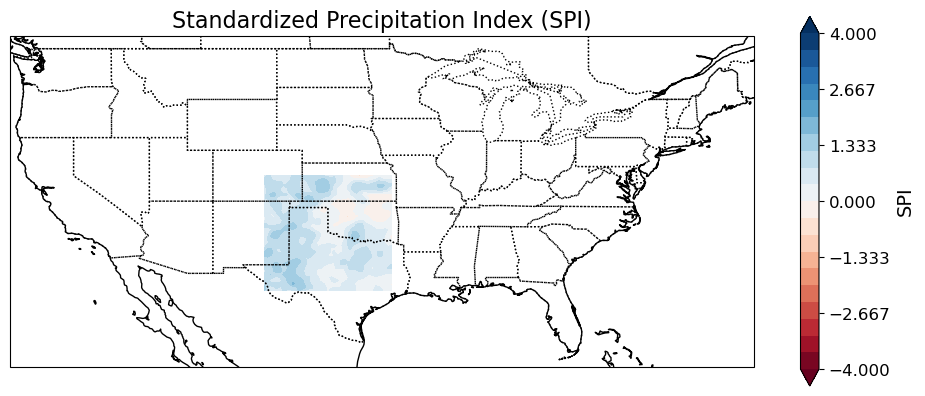

In [84]:
test_yr = spi_df[(spi_df['year'] == 2004)]

lon_unique = np.sort(test_yr['longitude'].unique())

lat_unique = np.sort(test_yr['latitude'].unique())

# Create 2D meshgrid
lon2d, lat2d = np.meshgrid(lon_unique, lat_unique)

# Interpolate scattered data onto the 2D grid
spi_grid = griddata(
    points=(test_yr['longitude'], test_yr['latitude']),
    values=test_yr['spi_3mo_avg'],
    xi=(lon2d, lat2d),
    method='linear'
)

# Define normalization centered at 0
norm = mcolors.TwoSlopeNorm(vmin=-4, vcenter=0, vmax=4)

fig = plt.figure(figsize=(12, 8))

ax = plt.axes(projection=ccrs.PlateCarree())

# Set extent to CONUS (continental US)
ax.set_extent([-125, -66.5, 24, 50], crs=ccrs.PlateCarree())

# Add features
ax.add_feature(cfeature.COASTLINE)

ax.add_feature(cfeature.BORDERS, linestyle=':')

ax.add_feature(cfeature.STATES, linestyle=':')

# Filled contour plot of SPI
cf = ax.contourf(
    lon2d, lat2d, spi_grid,
    levels=np.linspace(-4, 4, 21),  # smooth gradation
    cmap='RdBu',
    norm=norm,
    transform=ccrs.PlateCarree(),
    extend='both'
)

# Add colorbar
cb = plt.colorbar(cf, ax=ax, orientation='vertical', label='SPI', shrink=0.6)

cb.set_ticks(np.linspace(-4, 4, 7))

plt.title('Standardized Precipitation Index (SPI)')

plt.show()

In [9]:
# calculation warm-season domain average spi 

domain_average_spi = (spi_df.groupby(["year"])["spi_3mo_avg"].mean().reset_index(name="spi"))

# categorize years-months into SPI terciles

domain_average_spi["spi_tercile"] = pd.qcut(domain_average_spi["spi"], q=5, labels=["very dry", "dry", "normal", "wet", "very wet"])